# Advisor Workflow — Evaluation

Evaluates the structured outputs returned by the Advisor n8n workflow.

Each test case compares **expected** ground-truth values against **result** predictions
across eight fields:

| Field | Match strategy |
|---|---|
| `consultAcc` | Set equality (comma-split, strip spaces) |
| `maxPayment` (Installment) | Numeric \|diff\| ≤ 1e-3 |
| `maxTerm` | Numeric \|diff\| ≤ 1e-3 |
| `maxPaymentY2` (InstallmentY2) | Numeric \|diff\| ≤ 1e-3 |
| `maxPaymentY3` (InstallmentY3) | Numeric \|diff\| ≤ 1e-3 |
| `refPlanID` | Exact match (NaN ≡ "") |
| `DebtSituation` | Exact match + precision/recall/confusion matrix |
| `reConfirmMessage` | Exact match + precision/recall/confusion matrix |

A row is fully correct only when **all** eight fields match.

Results are written to **`advisor_eval_results.xlsx`** (two sheets):
- **`test_result`** — every row with per-field `match_*` columns and `row_match`.
- **`overview`** — accuracy table, per-class metrics, confusion matrices.

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

## 2. Configuration

In [2]:
RESULT_XLSX = Path("../actual_test_cases/advisor_result.xlsx")
OUTPUT_XLSX = Path("advisor_eval_results.xlsx")

NUMERIC_TOL = 1e-3
NONE_LABEL  = "none"   # sentinel for NaN / empty categorical values

DEBT_SITUATION_CLASSES      = ["DebtBurden", NONE_LABEL]
RECONFIRM_CLASSES_EXPECTED  = ["CLARIFY_HIGH_INSTALLMENT", "CLARIFY_LONG_TERM",
                                "CLARIFY_HIGH_INTEREST", NONE_LABEL]

## 3. Load Data

In [3]:
df = pd.read_excel(RESULT_XLSX)
print(f"Loaded {len(df)} rows  |  columns: {list(df.columns)}")
df.head(3)

Loaded 250 rows  |  columns: ['testId', 'consultAcc', 'DebtSituation', 'maxPayment', 'maxTerm', 'refPlanID', 'maxPaymentY2', 'maxPaymentY3', 'narrative', 'accText', 'offerText', 'accInfotoExtr', 'LastAImessage', 'userMessage', 'expected_consultAcc', 'expected_DebtSituation', 'expected_maxPayment', 'expected_maxTerm', 'expected_refPlanID', 'expected_maxPaymentY2', 'expected_maxPaymentY3', 'expected_reConfirmMessage', 'error', 'null_status_consultAcc', 'match_consultAcc', 'null_status_maxPayment', 'match_maxPayment', 'null_status_maxTerm', 'match_maxTerm', 'null_status_refPlanID', 'match_refPlanID', 'null_status_DebtSituation', 'match_DebtSituation', 'null_status_reConfirmMessage', 'match_reConfirmMessage', 'row_all_match', 'result_consultAcc', 'result_DebtSituation', 'result_maxPayment', 'result_maxTerm', 'result_refPlanID', 'result_maxPaymentY2', 'result_maxPaymentY3', 'result_reConfirmMessage']


,testId,consultAcc,DebtSituation,maxPayment,maxTerm,refPlanID,maxPaymentY2,maxPaymentY3,narrative,accText,...,match_reConfirmMessage,row_all_match,result_consultAcc,result_DebtSituation,result_maxPayment,result_maxTerm,result_refPlanID,result_maxPaymentY2,result_maxPaymentY3,result_reConfirmMessage
0,TC-0001,NaN,NaN,0,360,NaN,NaN,NaN,The customer has reviewed the proposed debt re...,"[{""account_number"": ""1xxxxxxx0804"", ""port"": ""ส...",...,True,False,"1xxxxxxx0804,1xxxxxxx0803,1xxxxxxx0805",DebtBurden,700.0,360.0,TDR0220260621103821,0.0,0.0,NaN
1,TC-0002,NaN,NaN,0,360,NaN,NaN,NaN,The user rejected the proposed 240-month restr...,"[{""account_number"": ""1xxxxxxx2398"", ""port"": ""ส...",...,True,False,"1xxxxxxx2398,1xxxxxxx2397",DebtBurden,0.0,60.0,TDR0120260621102006,NaN,NaN,NaN
2,TC-0003,NaN,NaN,0,360,NaN,NaN,NaN,The user found the proposed 240-month debt res...,"[{""account_number"": ""1xxxxxxx2398"", ""port"": ""ส...",...,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Helper Functions

In [4]:
def parse_acc_set(val) -> frozenset:
    """Split a comma-separated account string into a frozenset; NaN/''/whitespace → empty set."""
    if pd.isna(val) or str(val).strip() == "":
        return frozenset()
    return frozenset(s.strip() for s in str(val).split(",") if s.strip())


def to_float(val):
    """Convert to float; return None for NaN / empty string."""
    if pd.isna(val) or str(val).strip() == "":
        return None
    try:
        return float(val)
    except (ValueError, TypeError):
        return None


def numeric_match(a, b, tol: float = NUMERIC_TOL) -> bool:
    """True when both are absent (None), or |a - b| <= tol."""
    fa, fb = to_float(a), to_float(b)
    if fa is None and fb is None:
        return True
    if fa is None or fb is None:
        return False
    return abs(fa - fb) <= tol


def str_match(a, b) -> bool:
    """Exact string match; NaN and '' are treated as equivalent."""
    def norm(v):
        if pd.isna(v) or str(v).strip() == "":
            return ""
        return str(v).strip()
    return norm(a) == norm(b)


def normalize_cat(val, none_label: str = NONE_LABEL) -> str:
    """Normalise a categorical value; NaN / '' → none_label."""
    if pd.isna(val) or str(val).strip() == "":
        return none_label
    return str(val).strip()


print("Helpers ready.")

Helpers ready.


## 5. Compute Per-Field Match Columns

In [5]:
# Filter valid rows (no error)
valid = df[df["error"].isna()].copy()
skipped = len(df) - len(valid)
if skipped:
    print(f"⚠️  {skipped} row(s) had errors and are excluded from metrics.")
print(f"Evaluating {len(valid)} valid rows.")

# ── consultAcc — set match ──────────────────────────────────────────────────
valid["match_consultAcc"] = valid.apply(
    lambda r: parse_acc_set(r["expected_consultAcc"]) == parse_acc_set(r["result_consultAcc"]),
    axis=1,
)

# ── Installment (maxPayment) — numeric ─────────────────────────────────────
valid["match_maxPayment"] = valid.apply(
    lambda r: numeric_match(r["expected_maxPayment"], r["result_maxPayment"]),
    axis=1,
)

# ── maxTerm — numeric ───────────────────────────────────────────────────────
valid["match_maxTerm"] = valid.apply(
    lambda r: numeric_match(r["expected_maxTerm"], r["result_maxTerm"]),
    axis=1,
)

# ── InstallmentY2 (maxPaymentY2) — numeric ──────────────────────────────────
valid["match_maxPaymentY2"] = valid.apply(
    lambda r: numeric_match(r["expected_maxPaymentY2"], r["result_maxPaymentY2"]),
    axis=1,
)

# ── InstallmentY3 (maxPaymentY3) — numeric ──────────────────────────────────
valid["match_maxPaymentY3"] = valid.apply(
    lambda r: numeric_match(r["expected_maxPaymentY3"], r["result_maxPaymentY3"]),
    axis=1,
)

# ── refPlanID — exact match ─────────────────────────────────────────────────
valid["match_refPlanID"] = valid.apply(
    lambda r: str_match(r["expected_refPlanID"], r["result_refPlanID"]),
    axis=1,
)

# ── DebtSituation — exact match ─────────────────────────────────────────────
valid["match_DebtSituation"] = valid.apply(
    lambda r: str_match(r["expected_DebtSituation"], r["result_DebtSituation"]),
    axis=1,
)

# ── reConfirmMessage — exact match ──────────────────────────────────────────
valid["match_reConfirmMessage"] = valid.apply(
    lambda r: str_match(r["expected_reConfirmMessage"], r["result_reConfirmMessage"]),
    axis=1,
)

# ── Row-level all-match ─────────────────────────────────────────────────────
MATCH_COLS = [
    "match_consultAcc",
    "match_maxPayment",
    "match_maxTerm",
    "match_maxPaymentY2",
    "match_maxPaymentY3",
    "match_refPlanID",
    "match_DebtSituation",
    "match_reConfirmMessage",
]
valid["row_match"] = valid[MATCH_COLS].all(axis=1)

# Summary
print("\nPer-field match counts:")
summary = {col: valid[col].sum() for col in MATCH_COLS + ["row_match"]}
for col, cnt in summary.items():
    print(f"  {col:30s}: {cnt:3d} / {len(valid)}  ({cnt/len(valid):.1%})")

Evaluating 250 valid rows.

Per-field match counts:
  match_consultAcc              : 148 / 250  (59.2%)
  match_maxPayment              : 182 / 250  (72.8%)
  match_maxTerm                 : 185 / 250  (74.0%)
  match_maxPaymentY2            : 127 / 250  (50.8%)
  match_maxPaymentY3            : 127 / 250  (50.8%)
  match_refPlanID               : 114 / 250  (45.6%)
  match_DebtSituation           : 180 / 250  (72.0%)
  match_reConfirmMessage        : 200 / 250  (80.0%)
  row_match                     :  22 / 250  (8.8%)


## 6. Overall Field-Level Accuracy

In [6]:
field_labels = {
    "match_consultAcc":       "consultAcc",
    "match_maxPayment":       "Installment (maxPayment)",
    "match_maxTerm":          "maxTerm",
    "match_maxPaymentY2":     "InstallmentY2 (maxPaymentY2)",
    "match_maxPaymentY3":     "InstallmentY3 (maxPaymentY3)",
    "match_refPlanID":        "refPlanID",
    "match_DebtSituation":    "DebtSituation",
    "match_reConfirmMessage": "reConfirmMessage",
    "row_match":              "ALL fields (row match)",
}

accuracy_rows = []
for col, label in field_labels.items():
    n_correct = valid[col].sum()
    n_total   = len(valid)
    accuracy_rows.append({
        "field":      label,
        "correct":    int(n_correct),
        "total":      n_total,
        "accuracy":   round(n_correct / n_total, 4),
    })

acc_df = pd.DataFrame(accuracy_rows)

print("=" * 60)
print("FIELD ACCURACY SUMMARY")
print("=" * 60)
for _, row in acc_df.iterrows():
    bar = "█" * int(row["accuracy"] * 30)
    print(f"  {row['field']:35s}: {row['correct']:3d}/{row['total']}  ({row['accuracy']:.1%})  {bar}")

acc_df

FIELD ACCURACY SUMMARY
  consultAcc                         : 148/250  (59.2%)  █████████████████
  Installment (maxPayment)           : 182/250  (72.8%)  █████████████████████
  maxTerm                            : 185/250  (74.0%)  ██████████████████████
  InstallmentY2 (maxPaymentY2)       : 127/250  (50.8%)  ███████████████
  InstallmentY3 (maxPaymentY3)       : 127/250  (50.8%)  ███████████████
  refPlanID                          : 114/250  (45.6%)  █████████████
  DebtSituation                      : 180/250  (72.0%)  █████████████████████
  reConfirmMessage                   : 200/250  (80.0%)  ████████████████████████
  ALL fields (row match)             :  22/250  (8.8%)  ██


,field,correct,total,accuracy
0,consultAcc,148,250,0.592
1,Installment (maxPayment),182,250,0.728
2,maxTerm,185,250,0.740
3,InstallmentY2 (maxPaymentY2),127,250,0.508
4,InstallmentY3 (maxPaymentY3),127,250,0.508
5,refPlanID,114,250,0.456
6,DebtSituation,180,250,0.720
7,reConfirmMessage,200,250,0.800
8,ALL fields (row match),22,250,0.088


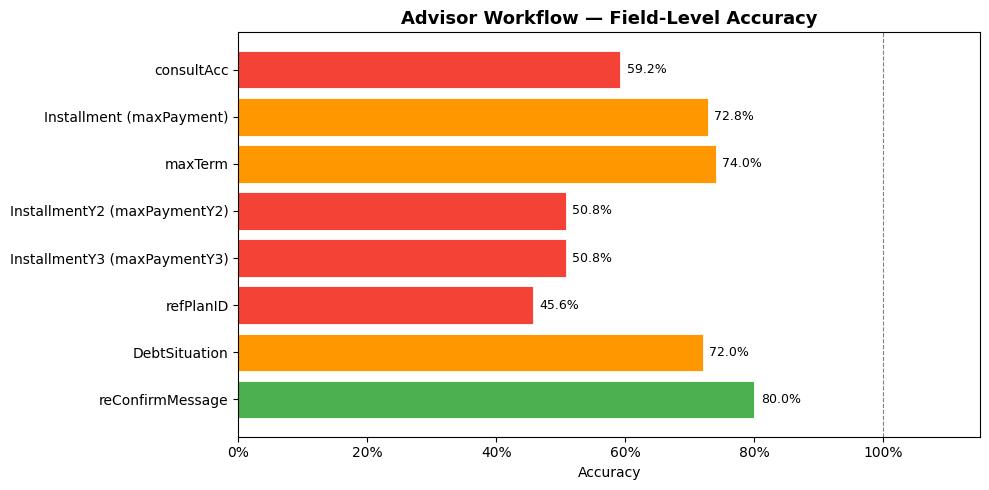

Chart saved → advisor_field_accuracy.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
labels  = [field_labels[c] for c in MATCH_COLS]
values  = [valid[c].mean() for c in MATCH_COLS]
colors  = ["#4caf50" if v >= 0.8 else "#ff9800" if v >= 0.6 else "#f44336" for v in values]

bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, values[::-1]):
    ax.text(
        min(val + 0.01, 1.0), bar.get_y() + bar.get_height() / 2,
        f"{val:.1%}", va="center", ha="left", fontsize=9,
    )
ax.set_xlim(0, 1.15)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axvline(1.0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Advisor Workflow — Field-Level Accuracy", fontsize=13, fontweight="bold")
ax.set_xlabel("Accuracy")
plt.tight_layout()
plt.savefig("advisor_field_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → advisor_field_accuracy.png")

## 7. Categorical Analysis — DebtSituation

Binary classification: `DebtBurden` vs `none` (NaN / empty).

In [8]:
ds_true = valid["expected_DebtSituation"].apply(normalize_cat)
ds_pred = valid["result_DebtSituation"].apply(normalize_cat)

# Determine all classes (expected + any extra in predictions)
ds_classes = DEBT_SITUATION_CLASSES
extra_ds = sorted(set(ds_pred.unique()) - set(ds_classes))
if extra_ds:
    print(f"Extra classes in predictions: {extra_ds}")
    ds_classes = ds_classes + extra_ds

print(f"DebtSituation classes: {ds_classes}")
print()

# Distribution
dist_ds = pd.DataFrame({
    "expected_count":  ds_true.value_counts(),
    "predicted_count": ds_pred.value_counts(),
}).reindex(ds_classes).fillna(0).astype(int)
dist_ds["delta"] = dist_ds["predicted_count"] - dist_ds["expected_count"]
print("Class distribution — DebtSituation")
dist_ds

DebtSituation classes: ['DebtBurden', 'none']

Class distribution — DebtSituation


,expected_count,predicted_count,delta
DebtBurden,201,171,-30
none,49,79,30


In [9]:
def per_class_metrics(y_true, y_pred, classes):
    rows = []
    for cls in classes:
        yt = (y_true == cls)
        yp = (y_pred == cls)
        if yt.sum() == 0 and yp.sum() == 0:
            continue
        cm_vals = confusion_matrix(yt, yp, labels=[False, True]).ravel()
        if len(cm_vals) == 4:
            tn, fp, fn, tp = cm_vals
        else:
            tn, fp, fn, tp = 0, 0, 0, 0
        rows.append({
            "class":       cls,
            "support":     int(yt.sum()),
            "TP":          int(tp),
            "FP":          int(fp),
            "FN":          int(fn),
            "TN":          int(tn),
            "precision":   round(precision_score(yt, yp, zero_division=0), 4),
            "recall":      round(recall_score(yt, yp, zero_division=0), 4),
            "f1":          round(f1_score(yt, yp, zero_division=0), 4),
            "specificity": round(tn / (tn + fp), 4) if (tn + fp) > 0 else float("nan"),
        })
    metrics_df = pd.DataFrame(rows)
    if metrics_df.empty:
        return metrics_df
    macro = {
        "class":       "macro avg",
        "support":     len(y_true),
        "TP":          metrics_df["TP"].sum(),
        "FP":          metrics_df["FP"].sum(),
        "FN":          metrics_df["FN"].sum(),
        "TN":          metrics_df["TN"].sum(),
        "precision":   round(metrics_df["precision"].mean(), 4),
        "recall":      round(metrics_df["recall"].mean(), 4),
        "f1":          round(metrics_df["f1"].mean(), 4),
        "specificity": round(metrics_df["specificity"].mean(), 4),
    }
    return pd.concat([metrics_df, pd.DataFrame([macro])], ignore_index=True)


ds_metrics = per_class_metrics(ds_true, ds_pred, ds_classes)
print("Per-class metrics — DebtSituation")
ds_metrics

Per-class metrics — DebtSituation


,class,support,TP,FP,FN,TN,precision,recall,f1,specificity
0,DebtBurden,201,151,20,50,29,0.8830,0.7512,0.8118,0.5918
1,none,49,29,50,20,151,0.3671,0.5918,0.4531,0.7512
2,macro avg,250,180,70,70,180,0.6250,0.6715,0.6324,0.6715


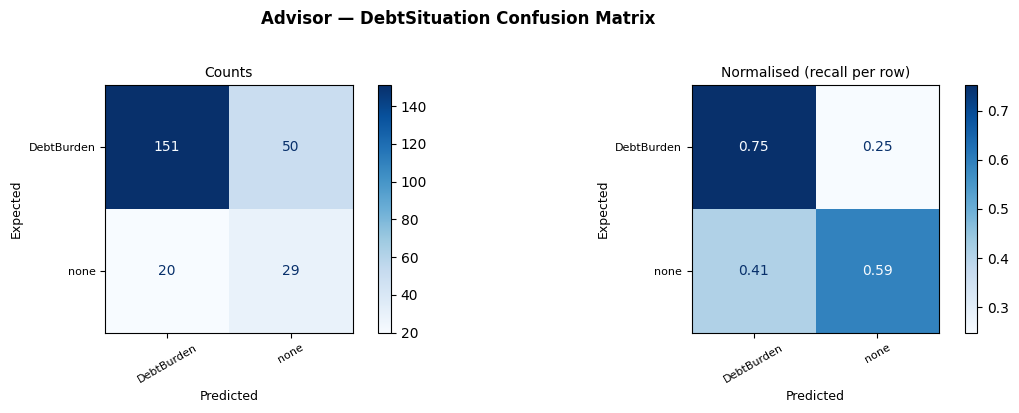

Chart saved → advisor_debtsituation_confusion_matrix.png


In [10]:
def plot_confusion_matrix(y_true, y_pred, classes, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, normalize, subtitle in zip(
        axes,
        [None, "true"],
        ["Counts", "Normalised (recall per row)"],
    ):
        cm_plot = confusion_matrix(y_true, y_pred, labels=classes, normalize=normalize)
        disp = ConfusionMatrixDisplay(cm_plot, display_labels=classes)
        disp.plot(ax=ax, colorbar=True, cmap="Blues",
                  values_format=".2f" if normalize else "d")
        ax.set_title(subtitle, fontsize=10)
        ax.set_xlabel("Predicted", fontsize=9)
        ax.set_ylabel("Expected", fontsize=9)
        ax.tick_params(axis="x", labelsize=8, rotation=30)
        ax.tick_params(axis="y", labelsize=8)
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved → {save_path}")


plot_confusion_matrix(
    ds_true, ds_pred, ds_classes,
    title="Advisor — DebtSituation Confusion Matrix",
    save_path="advisor_debtsituation_confusion_matrix.png",
)

In [11]:
print("=" * 60)
print("CLASSIFICATION REPORT — DebtSituation")
print("=" * 60)
print(classification_report(ds_true, ds_pred, labels=ds_classes, zero_division=0))
print(f"Overall Accuracy: {accuracy_score(ds_true, ds_pred):.4f}")

CLASSIFICATION REPORT — DebtSituation
              precision    recall  f1-score   support

  DebtBurden       0.88      0.75      0.81       201
        none       0.37      0.59      0.45        49

    accuracy                           0.72       250
   macro avg       0.63      0.67      0.63       250
weighted avg       0.78      0.72      0.74       250

Overall Accuracy: 0.7200


## 8. Categorical Analysis — reConfirmMessage

Multi-class classification across `CLARIFY_HIGH_INSTALLMENT`, `CLARIFY_LONG_TERM`,
`CLARIFY_HIGH_INTEREST`, and `none` (absent / NaN).

In [12]:
rc_true = valid["expected_reConfirmMessage"].apply(normalize_cat)
rc_pred = valid["result_reConfirmMessage"].apply(normalize_cat)

# Determine classes: expected classes first, then any extra from predictions
rc_classes = list(RECONFIRM_CLASSES_EXPECTED)
extra_rc = sorted(set(rc_pred.unique()) - set(rc_classes))
if extra_rc:
    print(f"Extra classes found in predictions (not in expected): {extra_rc}")
    rc_classes = rc_classes + extra_rc

print(f"reConfirmMessage classes: {rc_classes}")
print()

# Distribution
dist_rc = pd.DataFrame({
    "expected_count":  rc_true.value_counts(),
    "predicted_count": rc_pred.value_counts(),
}).reindex(rc_classes).fillna(0).astype(int)
dist_rc["delta"] = dist_rc["predicted_count"] - dist_rc["expected_count"]
print("Class distribution — reConfirmMessage")
dist_rc

Extra classes found in predictions (not in expected): ['CLARIFY_HIGH_Y2Y3']
reConfirmMessage classes: ['CLARIFY_HIGH_INSTALLMENT', 'CLARIFY_LONG_TERM', 'CLARIFY_HIGH_INTEREST', 'none', 'CLARIFY_HIGH_Y2Y3']

Class distribution — reConfirmMessage


,expected_count,predicted_count,delta
CLARIFY_HIGH_INSTALLMENT,46,25,-21
CLARIFY_LONG_TERM,24,14,-10
CLARIFY_HIGH_INTEREST,15,10,-5
none,165,200,35
CLARIFY_HIGH_Y2Y3,0,1,1


In [13]:
rc_metrics = per_class_metrics(rc_true, rc_pred, rc_classes)
print("Per-class metrics — reConfirmMessage")
rc_metrics

Per-class metrics — reConfirmMessage


,class,support,TP,FP,FN,TN,precision,recall,f1,specificity
0,CLARIFY_HIGH_INSTALLMENT,46,21,4,25,200,0.8400,0.4565,0.5915,0.9804
1,CLARIFY_LONG_TERM,24,11,3,13,223,0.7857,0.4583,0.5789,0.9867
2,CLARIFY_HIGH_INTEREST,15,10,0,5,235,1.0000,0.6667,0.8000,1.0000
3,none,165,158,42,7,43,0.7900,0.9576,0.8658,0.5059
4,CLARIFY_HIGH_Y2Y3,0,0,1,0,249,0.0000,0.0000,0.0000,0.9960
5,macro avg,250,200,50,50,950,0.6831,0.5078,0.5672,0.8938


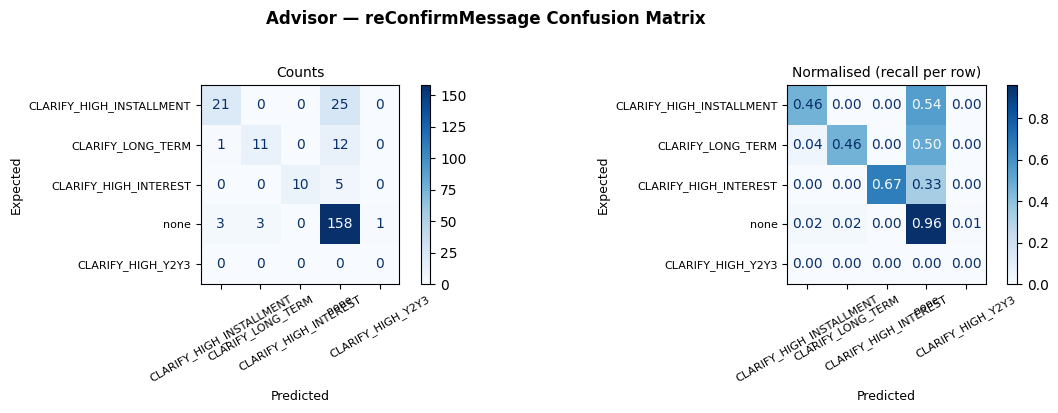

Chart saved → advisor_reconfirm_confusion_matrix.png


In [14]:
plot_confusion_matrix(
    rc_true, rc_pred, rc_classes,
    title="Advisor — reConfirmMessage Confusion Matrix",
    save_path="advisor_reconfirm_confusion_matrix.png",
)

In [15]:
print("=" * 60)
print("CLASSIFICATION REPORT — reConfirmMessage")
print("=" * 60)
print(classification_report(rc_true, rc_pred, labels=rc_classes, zero_division=0))
print(f"Overall Accuracy: {accuracy_score(rc_true, rc_pred):.4f}")

CLASSIFICATION REPORT — reConfirmMessage
                          precision    recall  f1-score   support

CLARIFY_HIGH_INSTALLMENT       0.84      0.46      0.59        46
       CLARIFY_LONG_TERM       0.79      0.46      0.58        24
   CLARIFY_HIGH_INTEREST       1.00      0.67      0.80        15
                    none       0.79      0.96      0.87       165
       CLARIFY_HIGH_Y2Y3       0.00      0.00      0.00         0

                accuracy                           0.80       250
               macro avg       0.68      0.51      0.57       250
            weighted avg       0.81      0.80      0.78       250

Overall Accuracy: 0.8000


## 9. Per-Class Metric Bar Charts

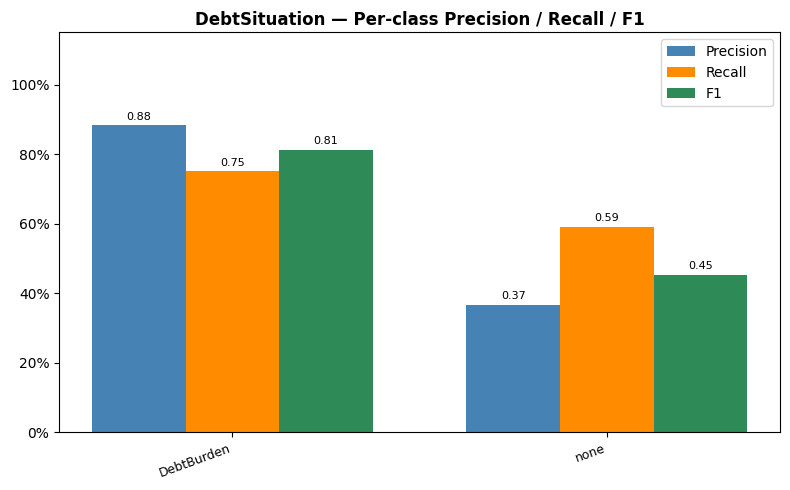

Chart saved → advisor_debtsituation_per_class.png


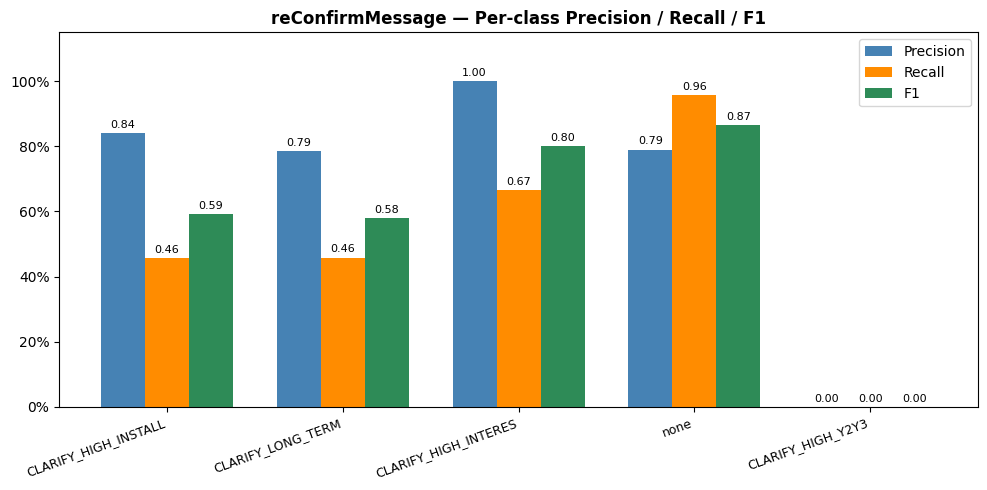

Chart saved → advisor_reconfirm_per_class.png


In [16]:
def plot_per_class_metrics(metrics_df, classes, title, save_path):
    per_class = metrics_df[metrics_df["class"].isin(classes)].set_index("class")
    # keep only classes that actually exist in the data
    classes = [c for c in classes if c in per_class.index]
    if not classes:
        print("No classes to plot.")
        return
    fig, ax = plt.subplots(figsize=(max(8, len(classes) * 2), 5))
    x = np.arange(len(classes))
    width = 0.25
    for offset, col, color, lbl in [
        (-width, "precision", "steelblue",  "Precision"),
        (0,      "recall",    "darkorange", "Recall"),
        (width,  "f1",        "seagreen",   "F1"),
    ]:
        vals = [per_class.loc[c, col] for c in classes]
        bars = ax.bar(x + offset, vals, width, label=lbl, color=color)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=8)
    short_classes = [c[:20] for c in classes]
    ax.set_xticks(x)
    ax.set_xticklabels(short_classes, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Chart saved → {save_path}")


plot_per_class_metrics(
    ds_metrics, ds_classes,
    title="DebtSituation — Per-class Precision / Recall / F1",
    save_path="advisor_debtsituation_per_class.png",
)
plot_per_class_metrics(
    rc_metrics, rc_classes,
    title="reConfirmMessage — Per-class Precision / Recall / F1",
    save_path="advisor_reconfirm_per_class.png",
)

## 10. Mismatch Cases

Shows all rows where at least one field did not match, broken down by field.

In [17]:
n_mismatch = (~valid["row_match"]).sum()
print(f"{n_mismatch} row(s) with at least one field mismatch  (out of {len(valid)} valid rows).\n")

228 row(s) with at least one field mismatch  (out of 250 valid rows).



### 10.1 consultAcc mismatches

In [18]:
mm_acc = valid[~valid["match_consultAcc"]][["testId", "expected_consultAcc", "result_consultAcc"]].copy()
print(f"consultAcc mismatches: {len(mm_acc)}")
mm_acc.reset_index(drop=True)

consultAcc mismatches: 102


,testId,expected_consultAcc,result_consultAcc
0,TC-0003,"1xxxxxxx2398,1xxxxxxx2397",NaN
1,TC-0005,NaN,"1xxxxxxx1232,1xxxxxxx1231"
2,TC-0007,1xxxxxxx1334,NaN
3,TC-0009,"1xxxxxxx1986,1xxxxxxx1985",NaN
4,TC-0010,NaN,1xxxxxxx3722
...,...,...,...
97,TC-0240,"1xxxxxxx1986,1xxxxxxx1985",NaN
98,TC-0241,"1xxxxxxx3620,1xxxxxxx3619,1xxxxxxx3618","1xxxxxxx3620,1xxxxxxx3619"
99,TC-0242,NaN,"1xxxxxxx2753,1xxxxxxx2755,1xxxxxxx2754"
100,TC-0244,NaN,1xxxxxxx2636


### 10.2 Installment (maxPayment) mismatches

In [19]:
mm_pay = valid[~valid["match_maxPayment"]][["testId", "expected_maxPayment", "result_maxPayment"]].copy()
print(f"maxPayment mismatches: {len(mm_pay)}")
mm_pay.reset_index(drop=True)

maxPayment mismatches: 68


,testId,expected_maxPayment,result_maxPayment
0,TC-0003,0,NaN
1,TC-0004,0,NaN
2,TC-0006,0,501.0
3,TC-0007,600,NaN
4,TC-0009,0,NaN
...,...,...,...
63,TC-0227,800,NaN
64,TC-0229,800,NaN
65,TC-0230,10400,NaN
66,TC-0234,800,NaN


### 10.3 maxTerm mismatches

In [20]:
mm_term = valid[~valid["match_maxTerm"]][["testId", "expected_maxTerm", "result_maxTerm"]].copy()
print(f"maxTerm mismatches: {len(mm_term)}")
mm_term.reset_index(drop=True)

maxTerm mismatches: 65


,testId,expected_maxTerm,result_maxTerm
0,TC-0003,60,NaN
1,TC-0004,360,NaN
2,TC-0007,360,NaN
3,TC-0009,360,NaN
4,TC-0012,360,NaN
...,...,...,...
60,TC-0227,360,NaN
61,TC-0229,360,NaN
62,TC-0230,360,NaN
63,TC-0234,360,NaN


### 10.4 InstallmentY2 (maxPaymentY2) mismatches

In [21]:
mm_y2 = valid[~valid["match_maxPaymentY2"]][["testId", "expected_maxPaymentY2", "result_maxPaymentY2"]].copy()
print(f"maxPaymentY2 mismatches: {len(mm_y2)}")
mm_y2.reset_index(drop=True)

maxPaymentY2 mismatches: 123


,testId,expected_maxPaymentY2,result_maxPaymentY2
0,TC-0001,NaN,0.0
1,TC-0005,NaN,0.0
2,TC-0008,NaN,0.0
3,TC-0010,NaN,0.0
4,TC-0015,NaN,0.0
...,...,...,...
118,TC-0246,NaN,0.0
119,TC-0247,NaN,0.0
120,TC-0248,NaN,0.0
121,TC-0249,NaN,0.0


### 10.5 InstallmentY3 (maxPaymentY3) mismatches

In [22]:
mm_y3 = valid[~valid["match_maxPaymentY3"]][["testId", "expected_maxPaymentY3", "result_maxPaymentY3"]].copy()
print(f"maxPaymentY3 mismatches: {len(mm_y3)}")
mm_y3.reset_index(drop=True)

maxPaymentY3 mismatches: 123


,testId,expected_maxPaymentY3,result_maxPaymentY3
0,TC-0001,NaN,0.0
1,TC-0005,NaN,0.0
2,TC-0008,NaN,0.0
3,TC-0010,NaN,0.0
4,TC-0015,NaN,0.0
...,...,...,...
118,TC-0246,NaN,0.0
119,TC-0247,NaN,0.0
120,TC-0248,NaN,0.0
121,TC-0249,NaN,0.0


### 10.6 refPlanID mismatches

In [23]:
mm_plan = valid[~valid["match_refPlanID"]][["testId", "expected_refPlanID", "result_refPlanID"]].copy()
print(f"refPlanID mismatches: {len(mm_plan)}")
mm_plan.reset_index(drop=True)

refPlanID mismatches: 136


,testId,expected_refPlanID,result_refPlanID
0,TC-0003,TDR0120260621102006,NaN
1,TC-0004,TDR0320260621085331,NaN
2,TC-0006,TDR0220260621103712,NaN
3,TC-0007,TDR0420260621103821,NaN
4,TC-0009,TDR0220260621102914,NaN
...,...,...,...
131,TC-0240,TDR0220260621102914,NaN
132,TC-0241,TDR0220260621102914,NaN
133,TC-0245,TDR0420260621100229,TDR0220260621100229
134,TC-0249,TDR0420260621102914,TDR0220260621102914


### 10.7 DebtSituation mismatches

In [24]:
mm_ds = valid[~valid["match_DebtSituation"]][["testId", "expected_DebtSituation", "result_DebtSituation"]].copy()
print(f"DebtSituation mismatches: {len(mm_ds)}")

# False Negatives: expected DebtBurden, predicted none
fn_ds = valid[
    (ds_true == "DebtBurden") & (ds_pred == NONE_LABEL)
][["testId", "expected_DebtSituation", "result_DebtSituation"]]
# False Positives: expected none, predicted DebtBurden
fp_ds = valid[
    (ds_true == NONE_LABEL) & (ds_pred == "DebtBurden")
][["testId", "expected_DebtSituation", "result_DebtSituation"]]

print(f"  False Negatives (expected DebtBurden → predicted none): {len(fn_ds)}")
if not fn_ds.empty:
    print(fn_ds.to_string(index=False))

print(f"\n  False Positives (expected none → predicted DebtBurden): {len(fp_ds)}")
if not fp_ds.empty:
    print(fp_ds.to_string(index=False))

DebtSituation mismatches: 70
  False Negatives (expected DebtBurden → predicted none): 50
 testId expected_DebtSituation result_DebtSituation
TC-0003             DebtBurden                  NaN
TC-0007             DebtBurden                  NaN
TC-0009             DebtBurden                  NaN
TC-0011             DebtBurden                  NaN
TC-0017             DebtBurden                  NaN
TC-0018             DebtBurden                  NaN
TC-0022             DebtBurden                  NaN
TC-0023             DebtBurden                  NaN
TC-0032             DebtBurden                  NaN
TC-0034             DebtBurden                  NaN
TC-0038             DebtBurden                  NaN
TC-0044             DebtBurden                  NaN
TC-0053             DebtBurden                  NaN
TC-0054             DebtBurden                  NaN
TC-0065             DebtBurden                  NaN
TC-0070             DebtBurden                  NaN
TC-0072             DebtBu

### 10.8 reConfirmMessage mismatches

In [25]:
mm_rc = valid[~valid["match_reConfirmMessage"]][[
    "testId", "expected_reConfirmMessage", "result_reConfirmMessage"
]].copy()
print(f"reConfirmMessage mismatches: {len(mm_rc)}\n")

for cls in rc_classes:
    fn_rows = valid[(rc_true == cls) & (rc_pred != cls)]
    fp_rows = valid[(rc_true != cls) & (rc_pred == cls)]
    if fn_rows.empty and fp_rows.empty:
        continue
    print("=" * 70)
    print(f"[{cls}]  FN={len(fn_rows)}  FP={len(fp_rows)}")
    if not fn_rows.empty:
        print("  -- False Negatives (expected this label, predicted something else) --")
        for _, r in fn_rows.iterrows():
            pred = normalize_cat(r["result_reConfirmMessage"])
            print(f"    [{r['testId']}] predicted='{pred}'")
    if not fp_rows.empty:
        print("  -- False Positives (predicted this label, expected something else) --")
        for _, r in fp_rows.iterrows():
            exp = normalize_cat(r["expected_reConfirmMessage"])
            print(f"    [{r['testId']}] expected='{exp}'")
print("=" * 70)

reConfirmMessage mismatches: 50

[CLARIFY_HIGH_INSTALLMENT]  FN=25  FP=4
  -- False Negatives (expected this label, predicted something else) --
    [TC-0029] predicted='none'
    [TC-0042] predicted='none'
    [TC-0046] predicted='none'
    [TC-0048] predicted='none'
    [TC-0061] predicted='none'
    [TC-0063] predicted='none'
    [TC-0071] predicted='none'
    [TC-0081] predicted='none'
    [TC-0092] predicted='none'
    [TC-0093] predicted='none'
    [TC-0095] predicted='none'
    [TC-0105] predicted='none'
    [TC-0110] predicted='none'
    [TC-0111] predicted='none'
    [TC-0123] predicted='none'
    [TC-0125] predicted='none'
    [TC-0140] predicted='none'
    [TC-0153] predicted='none'
    [TC-0154] predicted='none'
    [TC-0170] predicted='none'
    [TC-0187] predicted='none'
    [TC-0212] predicted='none'
    [TC-0213] predicted='none'
    [TC-0221] predicted='none'
    [TC-0237] predicted='none'
  -- False Positives (predicted this label, expected something else) --
    [TC-

### 10.9 All-field mismatch rows

In [26]:
all_mm = valid[~valid["row_match"]].copy()

# Build a readable mismatch detail column
def build_mismatch_detail(row):
    parts = []
    if not row["match_consultAcc"]:
        parts.append(f"consultAcc: exp={row['expected_consultAcc']!r} → got={row['result_consultAcc']!r}")
    if not row["match_maxPayment"]:
        parts.append(f"maxPayment: exp={row['expected_maxPayment']} → got={row['result_maxPayment']}")
    if not row["match_maxTerm"]:
        parts.append(f"maxTerm: exp={row['expected_maxTerm']} → got={row['result_maxTerm']}")
    if not row["match_maxPaymentY2"]:
        parts.append(f"maxPaymentY2: exp={row['expected_maxPaymentY2']} → got={row['result_maxPaymentY2']}")
    if not row["match_maxPaymentY3"]:
        parts.append(f"maxPaymentY3: exp={row['expected_maxPaymentY3']} → got={row['result_maxPaymentY3']}")
    if not row["match_refPlanID"]:
        parts.append(f"refPlanID: exp={row['expected_refPlanID']!r} → got={row['result_refPlanID']!r}")
    if not row["match_DebtSituation"]:
        parts.append(f"DebtSituation: exp={row['expected_DebtSituation']!r} → got={row['result_DebtSituation']!r}")
    if not row["match_reConfirmMessage"]:
        parts.append(f"reConfirmMessage: exp={row['expected_reConfirmMessage']!r} → got={row['result_reConfirmMessage']!r}")
    return " | ".join(parts)

all_mm["mismatch_detail"] = all_mm.apply(build_mismatch_detail, axis=1)

display_cols = ["testId", "row_match"] + MATCH_COLS + ["mismatch_detail"]
print(f"{len(all_mm)} rows with at least one mismatch:")
all_mm[display_cols].reset_index(drop=True)

228 rows with at least one mismatch:


,testId,row_match,match_consultAcc,match_maxPayment,match_maxTerm,match_maxPaymentY2,match_maxPaymentY3,match_refPlanID,match_DebtSituation,match_reConfirmMessage,mismatch_detail
0,TC-0001,False,True,True,True,False,False,True,True,True,maxPaymentY2: exp=nan → got=0.0 | maxPaymentY3...
1,TC-0003,False,False,False,False,True,True,False,False,True,"consultAcc: exp='1xxxxxxx2398,1xxxxxxx2397' → ..."
2,TC-0004,False,True,False,False,True,True,False,True,False,maxPayment: exp=0 → got=nan | maxTerm: exp=360...
3,TC-0005,False,False,True,True,False,False,True,False,True,"consultAcc: exp=nan → got='1xxxxxxx1232,1xxxxx..."
4,TC-0006,False,True,False,True,True,True,False,True,True,maxPayment: exp=0 → got=501.0 | refPlanID: exp...
...,...,...,...,...,...,...,...,...,...,...,...
223,TC-0246,False,False,True,True,False,False,True,True,True,"consultAcc: exp=nan → got='1xxxxxxx0443,1xxxxx..."
224,TC-0247,False,True,True,True,False,False,True,True,True,maxPaymentY2: exp=nan → got=0.0 | maxPaymentY3...
225,TC-0248,False,True,True,True,False,False,True,True,True,maxPaymentY2: exp=nan → got=0.0 | maxPaymentY3...
226,TC-0249,False,True,True,True,False,False,False,True,True,maxPaymentY2: exp=nan → got=0.0 | maxPaymentY3...


## 11. Consolidated Mismatch Summary

Long-format table with **one row per (testId, field) failure**, plus a per-field mismatch count.  
Use this view to quickly filter or sort mismatches without sifting through the per-field subsections above.

In [ ]:
FIELD_MAP = {
    "consultAcc":       ("expected_consultAcc",      "result_consultAcc"),
    "maxPayment":       ("expected_maxPayment",       "result_maxPayment"),
    "maxTerm":          ("expected_maxTerm",          "result_maxTerm"),
    "maxPaymentY2":     ("expected_maxPaymentY2",     "result_maxPaymentY2"),
    "maxPaymentY3":     ("expected_maxPaymentY3",     "result_maxPaymentY3"),
    "refPlanID":        ("expected_refPlanID",        "result_refPlanID"),
    "DebtSituation":    ("expected_DebtSituation",    "result_DebtSituation"),
    "reConfirmMessage": ("expected_reConfirmMessage", "result_reConfirmMessage"),
}

rows = []
for _, row in valid.iterrows():
    for field, (exp_col, res_col) in FIELD_MAP.items():
        if not row[f"match_{field}"]:
            rows.append({
                "testId":   row["testId"],
                "field":    field,
                "expected": row[exp_col],
                "result":   row[res_col],
            })

mismatch_long_df = pd.DataFrame(rows, columns=["testId", "field", "expected", "result"])

print(f"Total field-level mismatches : {len(mismatch_long_df)}")
print(f"Unique test cases affected    : {mismatch_long_df['testId'].nunique()}\n")

# ── Per-field mismatch count ────────────────────────────────────────────────
field_counts = (
    mismatch_long_df["field"]
    .value_counts()
    .rename_axis("field")
    .reset_index(name="mismatch_count")
)
field_counts["pct_of_valid"] = (field_counts["mismatch_count"] / len(valid) * 100).round(1)
print("Mismatches per field:")
display(field_counts)

# ── Full long-format mismatch table ────────────────────────────────────────
print(f"\nFull mismatch table ({len(mismatch_long_df)} rows — one row per field-level failure):")
mismatch_long_df.reset_index(drop=True)

## 12. Save Results to Excel

In [27]:
# ── Build test_result sheet ──────────────────────────────────────────────────
result_df = df.copy()

# Re-attach computed match columns from 'valid'; rows with errors get NaN
for col in MATCH_COLS + ["row_match"]:
    result_df[col] = valid[col].reindex(result_df.index)

result_df["mismatch_detail"] = ""
mismatch_mask = ~valid["row_match"]
result_df.loc[valid[mismatch_mask].index, "mismatch_detail"] = all_mm["mismatch_detail"]

# ── Build overview ───────────────────────────────────────────────────────────
n_valid   = len(valid)
n_correct = int(valid["row_match"].sum())
n_errors  = skipped

summary_rows = [
    ["ADVISOR WORKFLOW EVALUATION OVERVIEW", ""],
    ["", ""],
    ["Run date",                  pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")],
    ["Source file",               str(RESULT_XLSX.name)],
    ["Total test cases",          len(df)],
    ["Valid (no error)",          n_valid],
    ["Rows with errors",          n_errors],
    ["All-field match (correct)", n_correct],
    ["All-field mismatch",        n_valid - n_correct],
    ["Overall row accuracy",      f"{n_correct / n_valid:.4f}"],
]
overview_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])

# ── Write Excel ───────────────────────────────────────────────────────────────
with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:

    row_cur = 0

    # Overview header
    overview_df.to_excel(writer, sheet_name="overview", index=False, startrow=row_cur)
    row_cur += len(overview_df) + 2

    # Field accuracy table
    pd.DataFrame([["FIELD ACCURACY"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False, startrow=row_cur)
    row_cur += 1
    acc_df.to_excel(writer, sheet_name="overview", index=False, startrow=row_cur)
    row_cur += len(acc_df) + 2

    # DebtSituation metrics
    pd.DataFrame([["DEBTSITUATION — PER-CLASS METRICS"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False, startrow=row_cur)
    row_cur += 1
    ds_metrics.to_excel(writer, sheet_name="overview", index=False, startrow=row_cur)
    row_cur += len(ds_metrics) + 1

    # DebtSituation confusion matrix
    pd.DataFrame([["DEBTSITUATION — CONFUSION MATRIX (rows=expected, cols=predicted)"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False, startrow=row_cur)
    row_cur += 1
    cm_ds = pd.DataFrame(
        confusion_matrix(ds_true, ds_pred, labels=ds_classes),
        index=[f"actual_{c}" for c in ds_classes],
        columns=[f"pred_{c}" for c in ds_classes],
    )
    cm_ds.to_excel(writer, sheet_name="overview", startrow=row_cur)
    row_cur += len(cm_ds) + 2

    # reConfirmMessage metrics
    pd.DataFrame([["RECONFIRMMESSAGE — PER-CLASS METRICS"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False, startrow=row_cur)
    row_cur += 1
    rc_metrics.to_excel(writer, sheet_name="overview", index=False, startrow=row_cur)
    row_cur += len(rc_metrics) + 1

    # reConfirmMessage confusion matrix
    pd.DataFrame([["RECONFIRMMESSAGE — CONFUSION MATRIX (rows=expected, cols=predicted)"]]).to_excel(
        writer, sheet_name="overview", index=False, header=False, startrow=row_cur)
    row_cur += 1
    cm_rc = pd.DataFrame(
        confusion_matrix(rc_true, rc_pred, labels=rc_classes),
        index=[f"actual_{c}" for c in rc_classes],
        columns=[f"pred_{c}" for c in rc_classes],
    )
    cm_rc.to_excel(writer, sheet_name="overview", startrow=row_cur)

    # test_result sheet
    result_df.to_excel(writer, sheet_name="test_result", index=False)

print(f"Saved → {OUTPUT_XLSX}")
print(f"  Sheets: overview, test_result")

Saved → advisor_eval_results.xlsx
  Sheets: overview, test_result
